In [1]:
#%pip install opencv-python --break-system-packages
#%pip install matplotlib --break-system-packages
#%pip install --upgrade numpy opencv-python matplotlib --break-system-packages
#%pip install pandas --break-system-packages

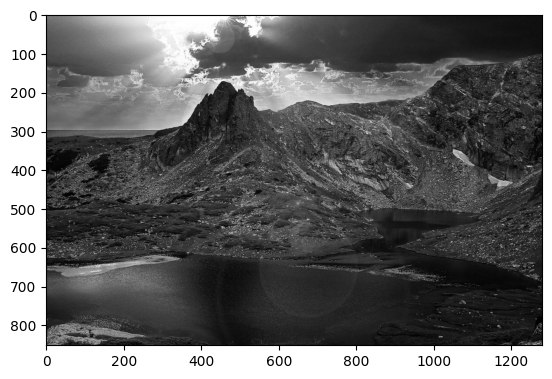

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy.sparse import diags, eye
from scipy.sparse.linalg import spsolve

img_bgr = cv2.imread('mountain.jpg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
img_gray = img_gray.astype(np.float32)/255.0

plt.imshow(img_gray, cmap='gray')
plt.show()

# --- PARTIE I : Test et Validation des Gradients ---

---

Cette section permet de valider la précision des gradients calculés manuellement ($dx$ et $dy$) en les comparant aux versions de référence.

AttributeError: 'numpy.ndarray' object has no attribute 'imshow'

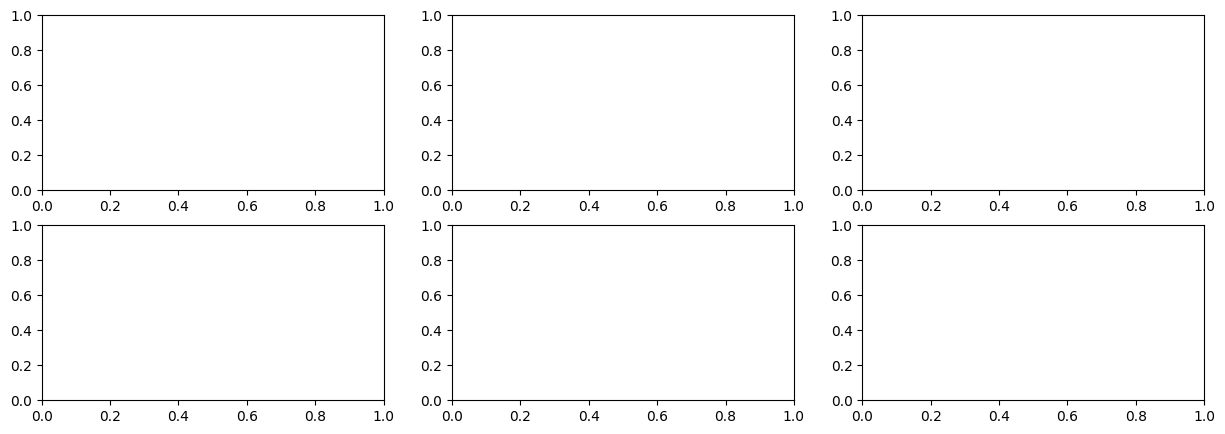

In [4]:
img_gray_flat = img_gray.flatten()
nb_lignes, nb_colonnes = img_gray.shape
nb_pixels = nb_lignes * nb_colonnes 

# Construction de Dx tq : 'u(p+1) - u(p)' derivee horizontale
dx_diff = -np.ones(nb_pixels)
dx_diag = np.ones(nb_pixels)

# gestion des bords : On met donc la différence à 0 pour la dernière colonne de chaque ligne.
dx_diff[nb_colonnes-1::nb_colonnes] = 0
dx_diag[nb_colonnes-1::nb_colonnes] = 0

Dx = diags([dx_diag, dx_diff], [0, 1], shape=(nb_pixels, nb_pixels))

# Construction de Dy tq : 'u(p+nb_colonnes) - u(p)' derivee horizontale
dy_diff = -np.ones(nb_pixels)
dy_diag = np.ones(nb_pixels)

#gestionn des bords : on mets la dernière ligne à zéro
dy_diag[-nb_colonnes:] = 0 
Dy = diags([dy_diag, dy_diff], [0, nb_colonnes], shape=(nb_pixels, nb_pixels))

# Calcul des gradients
grad_x_1D = Dx @ img_gray_flat
grad_y_1D = Dy @ img_gray_flat
# Reshape 
grad_x_2D = grad_x_1D.reshape(nb_lignes, nb_colonnes)
grad_y_2D = grad_y_1D.reshape(nb_lignes, nb_colonnes)

# Calcul du gradient différence finie
zero_col = np.zeros((img_gray.shape[0], 1))
img_gray_dx = np.hstack((img_gray[:, :-1] - img_gray[:, 1:], zero_col))

zero_lig = np.zeros((1, img_gray.shape[1]))
img_gray_dy = np.vstack((img_gray[:-1, :] - img_gray[1:, :], zero_lig)) 


# Affichage
fig, axes = plt.subplots(2, 3, figsize=(15, 5))

axes[0].imshow(grad_x_2D, cmap='gray')
axes[0].set_title("Dx calculé")

axes[1].imshow(img_gray_dx, cmap='gray')
axes[1].set_title("Dx différence finie")

verif_Dx = np.around(grad_x_2D.astype(np.double),6) == np.around(img_gray_dx.astype(np.double),6)

axes[2].imshow(verif_Dx, cmap='viridis', vmin=0, vmax=1)
axes[2].set_title("Zones identiques")

axes[3].imshow(grad_y_2D, cmap='gray')
axes[3].set_title("Dy calculé")

axes[4].imshow(img_gray_dy, cmap='gray')
axes[4].set_title("Dy différence finie")

verif_Dy = grad_y_2D == img_gray_dy 

axes[5].imshow(verif_Dy, cmap='viridis', vmin=0, vmax=1)
axes[5].set_title("Zones identiques")


plt.show()


# --- PARTIE II : Test et Validation de WLS ---

--- 

In [ ]:
alpha = 1.5
eps = 1e-4
lamb = 0.5

ax = 1 / (np.abs(grad_x_1D)**alpha + eps)
ay = 1 / (np.abs(grad_y_1D)**alpha + eps)

Ax = diags([ax], [0], shape=(nb_pixels, nb_pixels))
Ay = diags([ay], [0], shape=(nb_pixels, nb_pixels))

Lg = Dx.T @ Ax @ Dx + Dy.T @ Ay @ Dy

A_sys = eye(nb_pixels) + lamb * Lg

A_sys = A_sys.tocsr()
u_flat = spsolve(A_sys, img_gray_flat)
img_lisse = u_flat.reshape((nb_lignes, nb_colonnes))

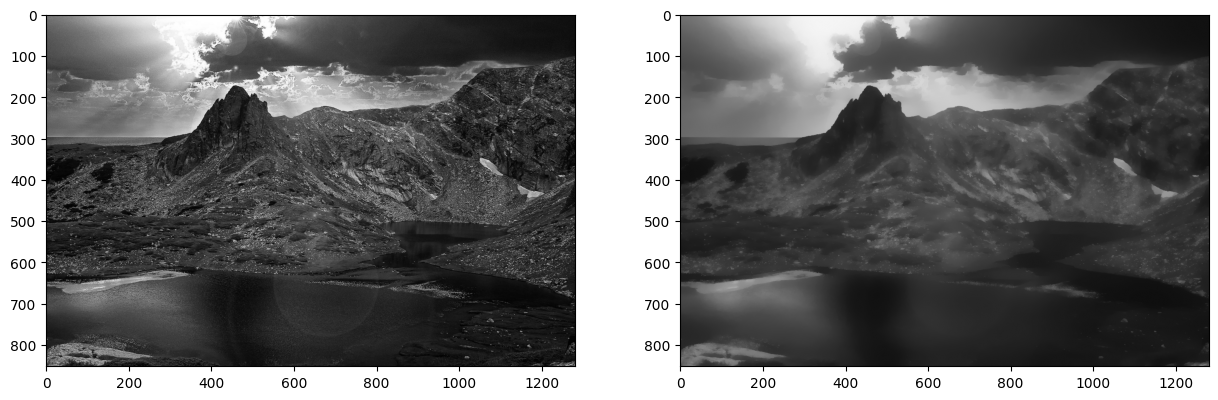

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].imshow(img_gray, cmap='gray', vmin=0, vmax=1)
axes[1].imshow(img_lisse, cmap='gray',  vmin=0, vmax=1)
plt.show()